In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
data = pd.read_csv("../dataset/Crop_recommendation.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [10]:
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [9]:
data.shape

(2200, 8)

In [8]:
import pandas as pd

data = pd.read_csv("../Dataset/Crop_recommendation.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [12]:
data["label"].unique()

<ArrowStringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

In [11]:
print(data.columns)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')


In [13]:
data.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [14]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


In [15]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [16]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [17]:
print(data["label"].value_counts())


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


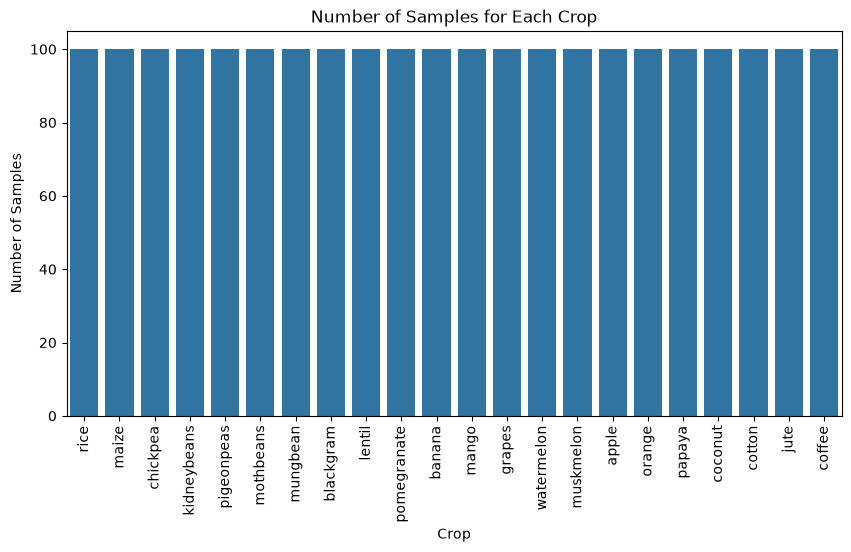

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=data, x="label")

plt.xticks(rotation=90)
plt.title("Number of Samples for Each Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Samples")
plt.show()

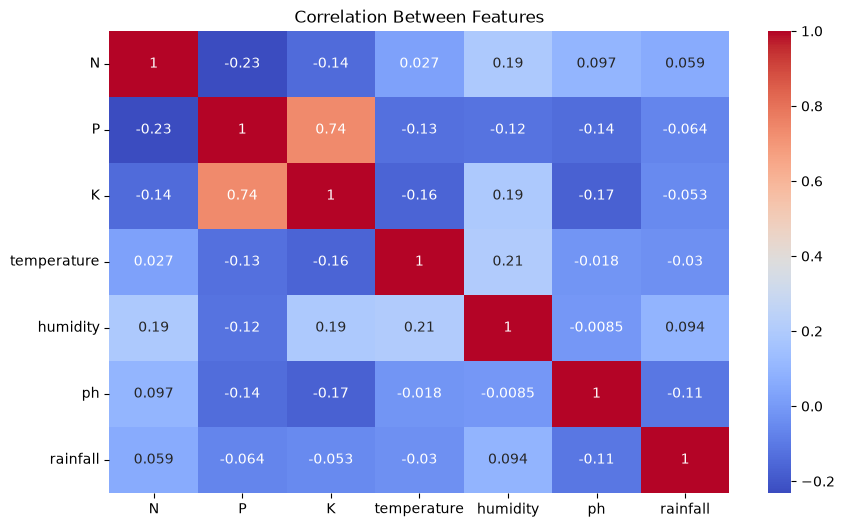

In [19]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    data.drop(columns=["label"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Features")
plt.show()

In [20]:
X = data.drop("label", axis=1)
y = data["label"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340

Target (y):
0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: str


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1760, 7)
Testing data: (440, 7)


In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [23]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.9954545454545455
Model Accuracy (%): 99.54545454545455


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

In [25]:
comparison = pd.DataFrame({
    "Actual Crop": y_test.values,
    "Predicted Crop": y_pred
})

comparison.head(20)

,Actual Crop,Predicted Crop
0,orange,orange
1,banana,banana
2,cotton,cotton
3,maize,maize
4,orange,orange
5,chickpea,chickpea
6,rice,rice
7,blackgram,blackgram
8,banana,banana
9,orange,orange


In [33]:
import joblib

joblib.dump(model, "../models/crop_recommendation_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [29]:
import os

print(os.getcwd())

c:\Users\LENOVO\Documents\Crop_Recommendation_App\notebooks


In [32]:
import os

print(os.path.exists("../models"))

True


In [31]:
import os

print(os.listdir(".."))

['app.py', 'create_dataset.py', 'Dataset', 'notebooks']


In [34]:
import joblib

loaded_model = joblib.load("../models/crop_recommendation_model.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [35]:
sample = [[90, 42, 43, 20.87, 82.0, 6.5, 202.9]]

prediction = loaded_model.predict(sample)

print("Recommended Crop:", prediction[0])

Recommended Crop: rice


c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


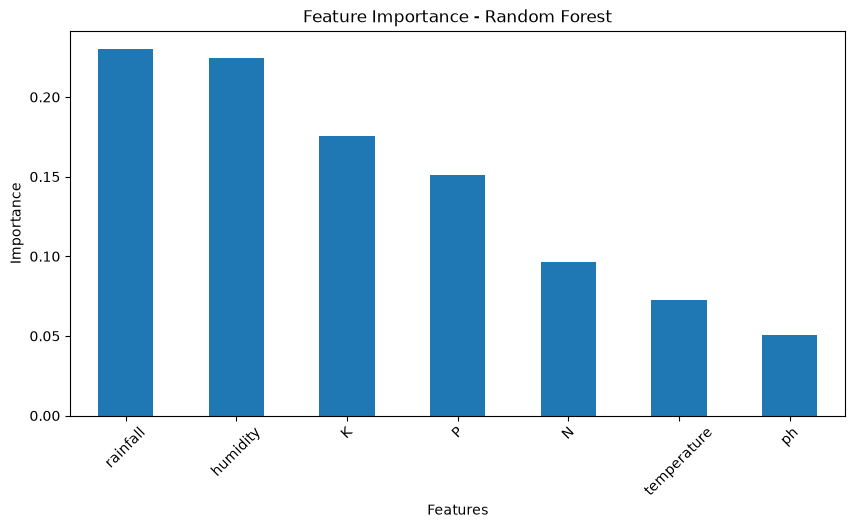

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance.plot(kind="bar")

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.show()

<Figure size 1200x1000 with 0 Axes>

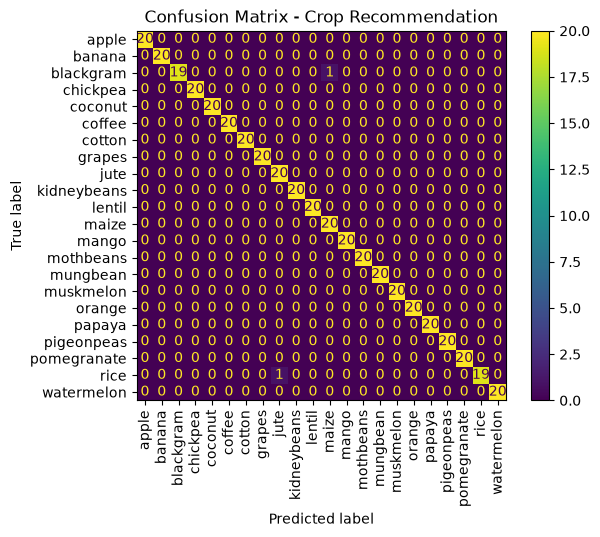

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(
    xticks_rotation=90,
    values_format="d"
)

plt.title("Confusion Matrix - Crop Recommendation")
plt.show()